In [7]:
# Imports
import os
import sys
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Sklearn
from sklearn.preprocessing import MinMaxScaler, RobustScaler

# Projekt-Pfad anpassen 
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from ML_Helpfunctions import Feature_Engeneering as fe
from ML_Helpfunctions import Load_Prepare_Data as LoadPrepareData
from ML_Helpfunctions import Pipeline_Utils as PipelineUtils 
from ML_Helpfunctions import RF_Utils as RFUtils
from ML_Algorithms import XGBoost_Run_Pipeline as XGBoostRunPipeline
 

BASE_DIR = Path().resolve().parent  # geht ein Verzeichnis nach oben von ML_Notebooks
INPUT_DIR = BASE_DIR / "Input"
OUTPUT_DIR = BASE_DIR / "Output"


CONFIG_XGB_ALL = {
    # ---- Pfade bleiben erhalten (lokales Setup) ----
    "paths": {
        "base": BASE_DIR,
        "input": INPUT_DIR,
        "output": OUTPUT_DIR,

        # Input Unterordner entsprechend deinem Beispiel
        "input_data": INPUT_DIR / "Input_Data",
        "input_models": INPUT_DIR / "Input_Models",
        "input_scaler": INPUT_DIR / "Input_Scaler",

        # Fixer Output-Pfad für Fehler-Metriken
        "output_error_metrics": OUTPUT_DIR / "Error_Metrics",

        # Falls du weitere Pfade brauchst, z.B. für Modelle / Loss Plots, kannst du sie hier ergänzen:
        "Models": OUTPUT_DIR / "Models",
        "Loss_Plots": OUTPUT_DIR / "Loss_Plots",
        "Model_Structures": OUTPUT_DIR / "Model_Structures",
    },

    # ---- Modellname und aktueller Timestamp ----
    "model_name": "XGBoost_Model",
    "time_stamp": datetime.now().strftime("%Y-%m-%d_%H%M%S"),

    # ---- Datensatz ----
    "dataset": "filtered_wanda_dataset.csv",

    # ---- Modellparameter (für RF) ----
    "n_estimators": 100,
    "max_depth": 25,
    "min_samples_split": 5,
    "min_samples_leaf": 3,
    "max_features": "sqrt",
    "random_state": 42,
    "n_jobs": 1,

    # ---- Modell-Dateinamen ----
    "model_params": {
        "saved_model_name": "XGBoost.pkl",
        "scaler_name": "scaler.pkl"
    },

    # ---- Zeitreihenparameter ----
    "lags": 2,
    "horizon": 3,
    "train_fraction": 0.3,
    "rolling_window_size": 5,

    # ---- Feature-Konfiguration ----
    "base_features": ['Volume_Flow', 'Pressure_Hall'],
    # "time_features": [
    #     'second', "minute", "minute_sin", "minute_cos", "hour", "hour_sin", "hour_cos",
    #     "day_of_month", "day_of_week", "is_weekend", "month", "month_sin", "month_cos"
    # ],
    "time_features": [],

    # ---- Feature Engineering ----
    "include_roll_mean": True,
    "include_roll_std": True,
    "scale_other_features": False,
    "scale_target": False,
}


✅ Experiment-Setup abgeschlossen. Run ID: 2025-07-03_134622_7785
📁 Ergebnisordner: C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Output\2025-07-03_134622_7785

Schritt 1: Lade Trainings- und Testdaten...
✔️ Datendatei gefunden: C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Input\Input_Data\filtered_wanda_dataset.csv
Geladen: 235421 Zeilen aus 'C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Input\Input_Data\filtered_wanda_dataset.csv' mit Zeitfeatures
✔️ Datendatei gefunden: C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Input\Input_Data\filtered_wanda_dataset.csv
Geladen: 235421 Zeilen aus 'C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Input\Input_Data\filtered_wanda_dataset.csv' mit Zeitfeatures

Schritt 2: Feature Engineering...

[DEBUG] Spaltennamen im Trainings-DataFrame NACH Feature Engineering:
['Volume_Flow', 'Pressure_Hall

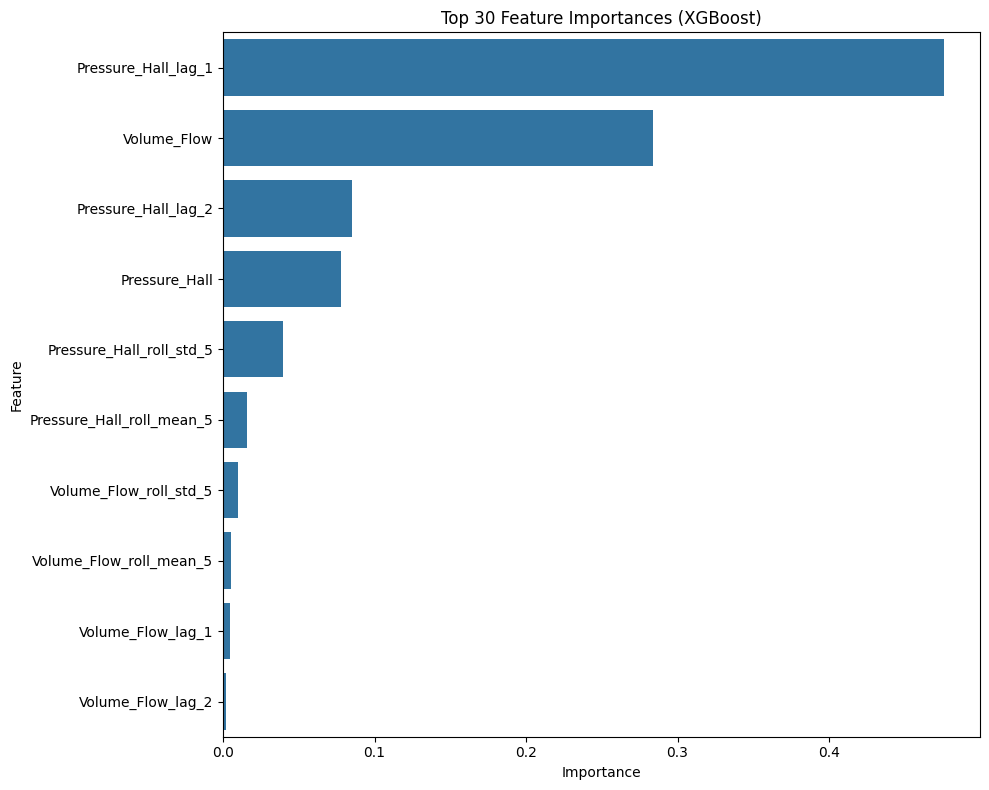

In [10]:
# ----- Funktionen (aus deinem Script übernommen) -----

# model, metrics, results = RFRunPipeline.run_full_pipeline_rf(CONFIG_RF_ALL)

model, metrics, results, full_feature_list = XGBoostRunPipeline.run_full_pipeline_xgb(CONFIG_XGB_ALL)

print("Extrahiere Feature-Wichtigkeit direkt aus dem XGBoost-Modell...")
importances = model.feature_importances_

# Erstelle den DataFrame direkt mit dem einzelnen Importance-Array.
# Der zweite Bug - die Verwendung der 'importances'-Variable aus dem letzten Schleifendurchlauf -
# ist damit ebenfalls behoben.
feature_importance_df = pd.DataFrame({
    'Feature': full_feature_list,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# --- KORREKTUR ENDE ---


print("\nTop Feature Importances (XGBoost):")
print(feature_importance_df.head(30))

# Optional: Plot (dieser Teil bleibt unverändert)
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_df.head(30), x='Importance', y='Feature')
plt.title("Top 30 Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()


Extrahiere Feature-Wichtigkeit direkt aus dem XGBoost-Modell...

Top Feature Importances (XGBoost):
                     Feature  Importance
0                Volume_Flow    0.601291
5        Pressure_Hall_lag_2    0.151891
4        Pressure_Hall_lag_1    0.136368
9   Pressure_Hall_roll_std_5    0.058720
1              Pressure_Hall    0.030270
8  Pressure_Hall_roll_mean_5    0.008523
2          Volume_Flow_lag_1    0.007458
3          Volume_Flow_lag_2    0.004047
7     Volume_Flow_roll_std_5    0.001040
6    Volume_Flow_roll_mean_5    0.000393


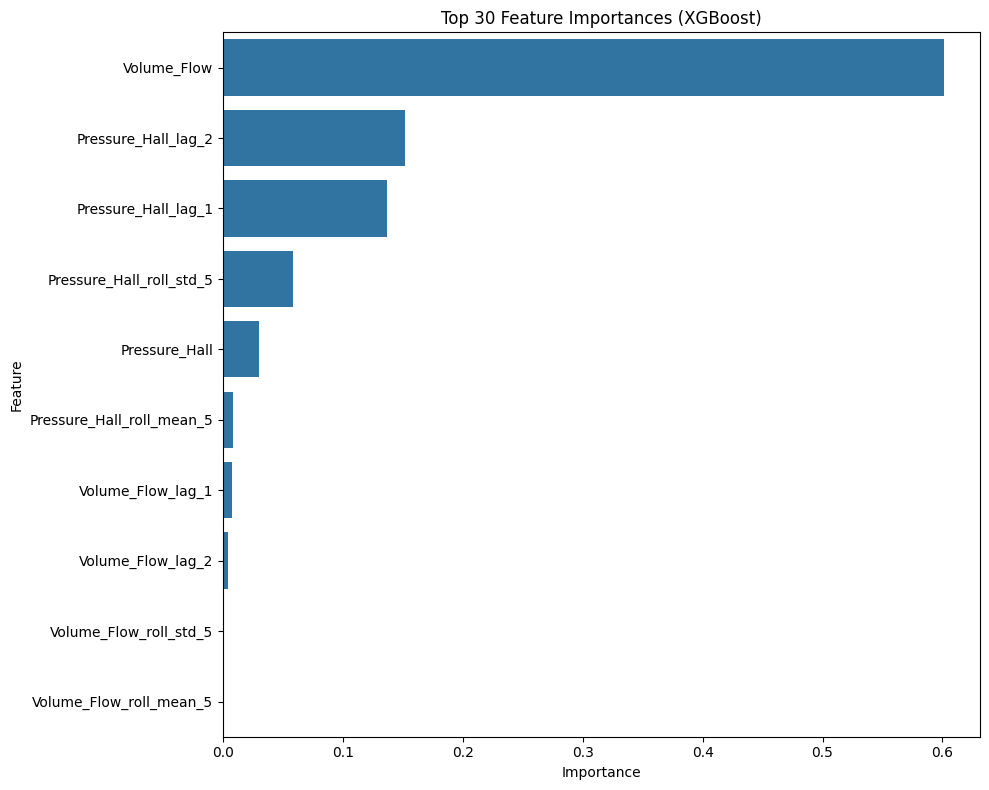

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----- Ihr Code zum Trainieren des Modells -----
# Annahme: Die folgenden Variablen sind nach dem Pipeline-Lauf verfügbar
# model, metrics, results, full_feature_list = XGBoostRunPipeline.run_full_pipeline_xgb(CONFIG_XGB_ALL)

# --- KORREKTUR START ---

# Die for-Schleife über "model.estimators_" wird entfernt.
# Dieses Vorgehen ist nur für Scikit-learns MultiOutputRegressor(RandomForest) korrekt.
# Ein trainiertes XGBoost-Modell hat stattdessen direkt ein .feature_importances_ Attribut,
# das die aggregierte Wichtigkeit aller Features enthält.

print("Extrahiere Feature-Wichtigkeit direkt aus dem XGBoost-Modell...")
importances = model.feature_importances_

# Erstelle den DataFrame direkt mit dem einzelnen Importance-Array.
# Der zweite Bug - die Verwendung der 'importances'-Variable aus dem letzten Schleifendurchlauf -
# ist damit ebenfalls behoben.
feature_importance_df = pd.DataFrame({
    'Feature': full_feature_list,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# --- KORREKTUR ENDE ---


print("\nTop Feature Importances (XGBoost):")
print(feature_importance_df.head(30))

# Optional: Plot (dieser Teil bleibt unverändert)
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_df.head(30), x='Importance', y='Feature')
plt.title("Top 30 Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()

In [3]:
model, full_feature_list = XGBoostRunPipeline.run_full_pipeline_XGBoost_without_save(CONFIG_XGB_ALL)

✅ Experiment-Setup abgeschlossen. Run ID: 2025-07-03_120554_3301
📁 Ergebnisordner: C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Output\2025-07-03_120554_3301

Schritt 1: Lade Trainings- und Testdaten...
✔️ Datendatei gefunden: C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Input\Input_Data\filtered_wanda_dataset.csv
Geladen: 235421 Zeilen aus 'C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Input\Input_Data\filtered_wanda_dataset.csv' mit Zeitfeatures
✔️ Datendatei gefunden: C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Input\Input_Data\filtered_wanda_dataset.csv
Geladen: 235421 Zeilen aus 'C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Input\Input_Data\filtered_wanda_dataset.csv' mit Zeitfeatures

Schritt 2: Feature Engineering...

[DEBUG] Spaltennamen im Trainings-DataFrame NACH Feature Engineering:
['Volume_Flow', 'Pressure_Hall